In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import ast
import os

# style plot
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [4]:
df = pd.read_csv("Youtube clean_final.csv")

## **Pelajari dataset**

In [5]:
# lihat 5 data teratas
df.head()

,Channel_Sumber,Author,Comment,Likes,Time,Tipe_Komentar,Comment_Raw,Comment_Clean,Tahun,Bulan,Hari,Jam,Panjang_Karakter,Jumlah_Kata,Comment_Norm,Tokens,Tokens_Stop,Tokens_Stem,Comment_Final
0,Jagat Review,@CheverrlynAdyba,Untuk link pembelian chamon 40 pro 5g kok gk a...,0,2026-03-21 13:04:52+00:00,Utama,Untuk link pembelian chamon 40 pro 5g kok gk a...,untuk link pembelian chamon pro 5g kok gk ada ...,2026,3,Sabtu,13,51,10,untuk link beli chamon pro 5g kok tidak ada bang,"['untuk', 'link', 'beli', 'chamon', 'pro', '5g...","['link', 'beli', 'chamon', 'pro', '5g']","['link', 'beli', 'chamon', 'pro', '5g']",link beli chamon pro 5g
1,Jagat Review,@caesarrizkie9742,"Ngomongin Rog kah ?, kameranya makin menurun, ...",0,2026-03-17 20:41:02+00:00,Utama,"Ngomongin Rog kah ?, kameranya makin menurun, ...","ngomongin rog kah ?, kameranya makin menurun, ...",2026,3,Selasa,20,151,24,ngomongin rog kah kamera makin turun karena sa...,"['ngomongin', 'rog', 'kah', 'kamera', 'makin',...","['ngomongin', 'rog', 'kah', 'kamera', 'turun',...","['ngomongin', 'rog', 'kah', 'kamera', 'turun',...",ngomongin rog kah kamera turun lihat review ca...
2,Jagat Review,@adealfian664,Sebagai user Samsung. One UI itu UI paling ena...,0,2026-03-13 23:27:54+00:00,Utama,Sebagai user Samsung. One UI itu UI paling ena...,sebagai user samsung. one ui itu ui paling ena...,2026,3,Jumat,23,603,116,bagai user samsung one ui itu ui paling enak u...,"['bagai', 'user', 'samsung', 'one', 'ui', 'itu...","['user', 'samsung', 'one', 'ui', 'ui', 'enak',...","['user', 'samsung', 'one', 'ui', 'ui', 'enak',...",user samsung one ui ui enak ui ui if you can t...
3,Jagat Review,@RsyatLyioz,"Tecno pova 7 ultra 5g ,bg",0,2026-03-12 20:11:30+00:00,Utama,"Tecno pova 7 ultra 5g ,bg","tecno pova ultra 5g ,bg",2026,3,Kamis,20,23,5,tecno pova ultra 5g bg,"['tecno', 'pova', 'ultra', '5g', 'bg']","['tecno', 'pova', 'ultra', '5g']","['tecno', 'pova', 'ultra', '5g']",tecno pova ultra 5g
4,Jagat Review,@CitraUtut,bang tolong buatin dong rekomendasi buat lebar...,2,2026-03-02 23:12:23+00:00,Utama,bang tolong buatin dong rekomendasi buat lebar...,bang tolong buatin dong rekomendasi buat lebaran,2026,3,Senin,23,48,7,bang tolong buatin dong rekomendasi buat lebaran,"['bang', 'tolong', 'buatin', 'dong', 'rekomend...","['tolong', 'buatin', 'rekomendasi', 'lebaran']","['tolong', 'buatin', 'rekomendasi', 'lebaran']",tolong buatin rekomendasi lebaran


In [6]:
# ukuran dataset
print("Shape dataset:", df.shape)

Shape dataset: (7199, 19)


In [7]:
# nama kolom
print(df.columns.tolist())

['Channel_Sumber', 'Author', 'Comment', 'Likes', 'Time', 'Tipe_Komentar', 'Comment_Raw', 'Comment_Clean', 'Tahun', 'Bulan', 'Hari', 'Jam', 'Panjang_Karakter', 'Jumlah_Kata', 'Comment_Norm', 'Tokens', 'Tokens_Stop', 'Tokens_Stem', 'Comment_Final']


In [8]:
# info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7199 entries, 0 to 7198
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Channel_Sumber    7199 non-null   object
 1   Author            7199 non-null   object
 2   Comment           7199 non-null   object
 3   Likes             7199 non-null   int64 
 4   Time              7199 non-null   object
 5   Tipe_Komentar     7199 non-null   object
 6   Comment_Raw       7199 non-null   object
 7   Comment_Clean     7199 non-null   object
 8   Tahun             7199 non-null   int64 
 9   Bulan             7199 non-null   int64 
 10  Hari              7199 non-null   object
 11  Jam               7199 non-null   int64 
 12  Panjang_Karakter  7199 non-null   int64 
 13  Jumlah_Kata       7199 non-null   int64 
 14  Comment_Norm      7199 non-null   object
 15  Tokens            7199 non-null   object
 16  Tokens_Stop       7199 non-null   object
 17  Tokens_Stem   

In [9]:
# cek missing value
df.isnull().sum()

,0
Channel_Sumber,0
Author,0
Comment,0
Likes,0
Time,0
Tipe_Komentar,0
Comment_Raw,0
Comment_Clean,0
Tahun,0
Bulan,0


## **Buat kolom Brand HP dari isi komentar**

In [10]:
brand_keywords = {
    'Samsung': ['samsung', 'galaxy'],
    'Xiaomi': ['xiaomi', 'redmi', 'poco'],
    'Infinix': ['infinix'],
    'Tecno': ['tecno'],
    'Realme': ['realme'],
    'Vivo': ['vivo'],
    'Oppo': ['oppo'],
    'iPhone': ['iphone', 'apple'],
    'Asus': ['asus', 'rog'],
}

In [11]:
def detect_brand(comment):
    comment = str(comment).lower()

    for brand, keywords in brand_keywords.items():
        for keyword in keywords:
            if keyword in comment:
                return brand

    return 'Lainnya'

In [12]:
df['Brand'] = df['Comment_Final'].apply(detect_brand)

In [13]:
df[['Comment_Final','Brand']].head(10)

,Comment_Final,Brand
0,link beli chamon pro 5g,Lainnya
1,ngomongin rog kah kamera turun lihat review ca...,Asus
2,user samsung one ui ui enak ui ui if you can t...,Samsung
3,tecno pova ultra 5g,Tecno
4,tolong buatin rekomendasi lebaran,Lainnya
5,infinix gt30 pro harga juta tau harga asli jut...,Infinix
6,beli toko,Lainnya
7,samsung s24fe5g aman kah beli,Samsung
8,bingung seri juta bagus bagus beli handphone l...,Infinix
9,camera camon game gt,Lainnya


## **Buat sentiment analysis rule-based**

In [14]:
positive_words = [
    'bagus',
    'keren',
    'mantap',
    'baik',
    'cepat',
    'murah',
    'worth it',
    'love',
    'suka',
    'terbaik',
    'recommended',
    'oke',
    'gacor',
    'memuaskan',
    'top'
]

In [15]:
negative_words = [
    'jelek',
    'buruk',
    'mahal',
    'lemot',
    'lambat',
    'rusak',
    'kecewa',
    'boros',
    'panas',
    'lag',
    'error',
    'parah',
    'zonk'
]

In [16]:
def sentiment_rule_based(text):
    text = str(text).lower()

    pos_score = 0
    neg_score = 0

    for word in positive_words:
        if word in text:
            pos_score += 1

    for word in negative_words:
        if word in text:
            neg_score += 1

    if pos_score > neg_score:
        return 'Positif'

    elif neg_score > pos_score:
        return 'Negatif'

    else:
        return 'Netral'

## **Generate kolom sentiment**

In [17]:
df['Sentiment'] = df['Comment_Final'].apply(sentiment_rule_based)

In [18]:
df[['Comment_Final','Sentiment']].head(15)

,Comment_Final,Sentiment
0,link beli chamon pro 5g,Netral
1,ngomongin rog kah kamera turun lihat review ca...,Positif
2,user samsung one ui ui enak ui ui if you can t...,Negatif
3,tecno pova ultra 5g,Netral
4,tolong buatin rekomendasi lebaran,Netral
5,infinix gt30 pro harga juta tau harga asli jut...,Netral
6,beli toko,Netral
7,samsung s24fe5g aman kah beli,Netral
8,bingung seri juta bagus bagus beli handphone l...,Positif
9,camera camon game gt,Netral


## **Distribusi label sentiment**

In [19]:
print(df['Sentiment'].value_counts())

Sentiment
Netral     5963
Positif    1036
Negatif     200
Name: count, dtype: int64


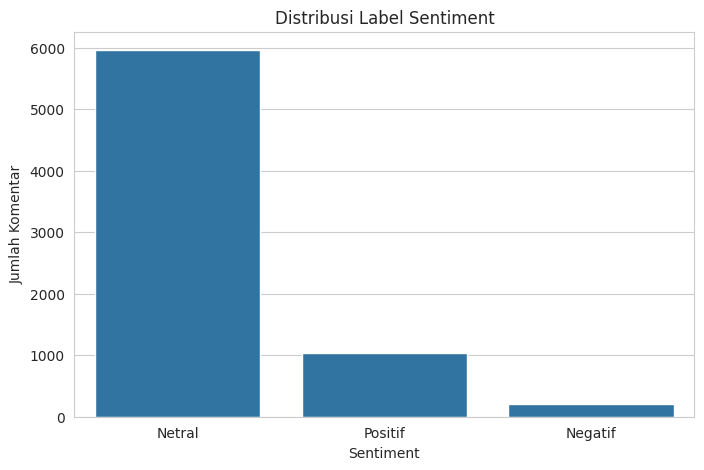

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Sentiment',
    order=df['Sentiment'].value_counts().index
)

plt.title('Distribusi Label Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Jumlah Komentar')

plt.show()

## **Distribusi sentiment per brand**

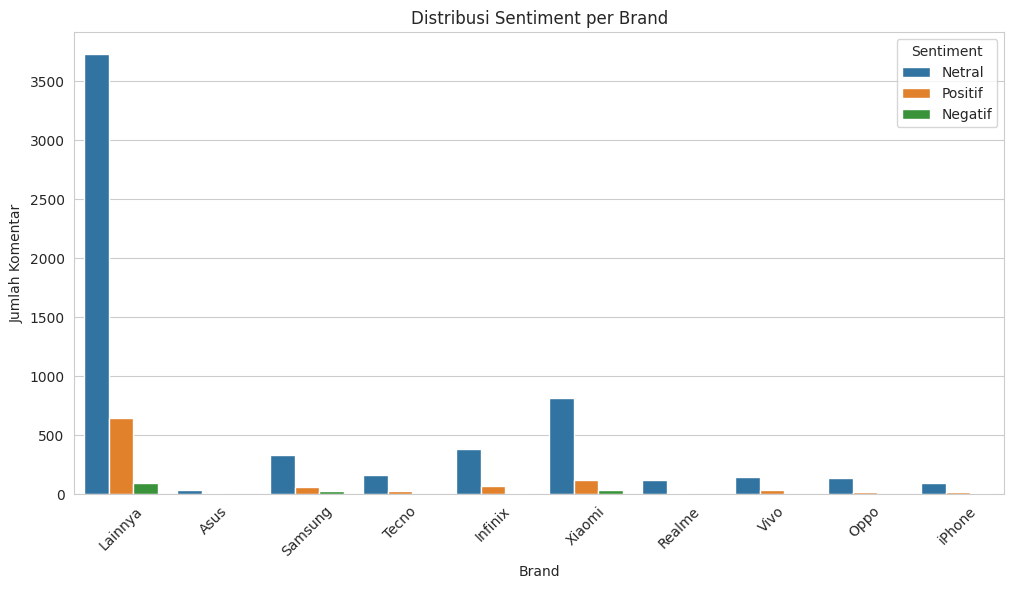

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='Brand',
    hue='Sentiment'
)

plt.xticks(rotation=45)

plt.title('Distribusi Sentiment per Brand')
plt.xlabel('Brand')
plt.ylabel('Jumlah Komentar')

plt.show()

## **Bar chart jumlah komentar per brand**

In [ ]:
brand_count = df['Brand'].value_counts()

print(brand_count)

Brand
Lainnya    4474
Xiaomi      976
Infinix     474
Samsung     426
Tecno       198
Vivo        184
Oppo        157
Realme      139
iPhone      126
Asus         45
Name: count, dtype: int64


## **Identifikasi brand yang komentarnya sedikit**

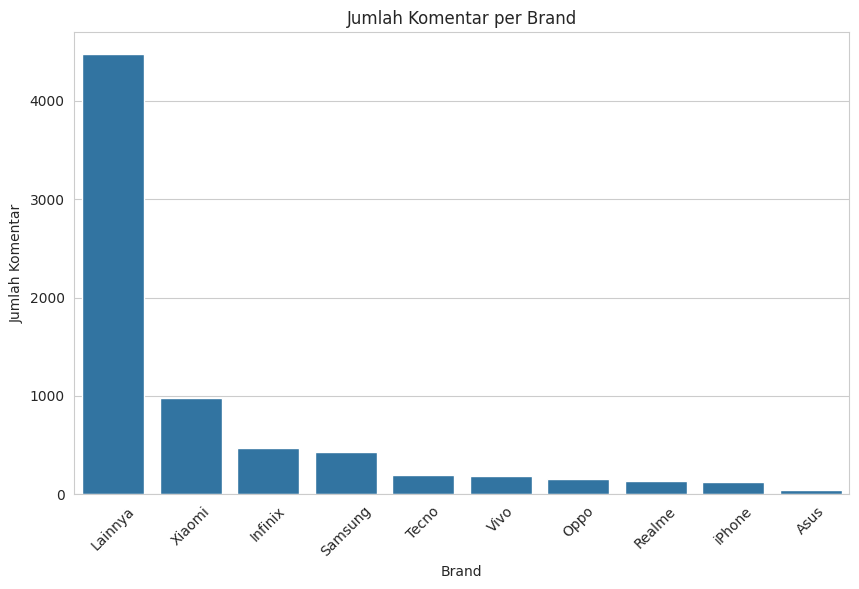

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=brand_count.index,
    y=brand_count.values
)

plt.xticks(rotation=45)

plt.title('Jumlah Komentar per Brand')
plt.xlabel('Brand')
plt.ylabel('Jumlah Komentar')

plt.show()

In [ ]:
brand_count.sort_values()

,count
Brand,
Asus,45
iPhone,126
Realme,139
Oppo,157
Vivo,184
Tecno,198
Samsung,426
Infinix,474
Xiaomi,976


In [ ]:
brand_count.sort_values().head(5)

,count
Brand,
Asus,45
iPhone,126
Realme,139
Oppo,157
Vivo,184


## **Hasil**

In [ ]:
df.to_csv(
    "youtube_eda_with_brand_sentiment.csv",
    index=False
)